## Model 2: Hierarchical Poisson (season-specific strengths)

**Backtest:** train through 2024/25, predict table 2025/26 (`2526`).

### Technical description

For match $n$ in season $s_n$:

$$\lambda_{h,n} = \exp(\alpha + \text{att}_{s_n, h_n} - \text{def}_{s_n, a_n}), \quad
  G_{h,n} \sim \text{Poisson}(\lambda_{h,n})$$

Team effects are **hierarchical** within each season (non-centered):

$$\text{att}_{s,t} = \sigma_{\text{att}} \cdot z^{\text{att}}_{s,t} - \text{mean}_t(\sigma_{\text{att}} z^{\text{att}}_{s,\cdot})$$

with $z^{\text{att}}_{s,t}, z^{\text{def}}_{s,t} \sim \mathcal{N}(0,1)$.

**Extra parameters vs Model 1:** $\sigma_{\text{att}}, \sigma_{\text{def}}$ — spread of team strengths within a season.

### Difference from Model 1 & justification

| Model 1 | Model 2 |
|---------|---------|
| One $(\text{att}, \text{def})$ per team for all seasons | $(\text{att}, \text{def})$ **per season** per team |
| Cannot capture form/transfers | $\sigma$ parameters learn how much teams differ each year |
| Simpler, fewer effective parameters | Richer; forecast uses **last training season** strengths |

We expect Model 2 to fit match-level likelihood better when team quality shifts over time, at the cost of more parameters and potentially noisier forecasts for promoted clubs.


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

from helping_functions import (
    load_matches,
    prepare_stan_data_hierarchical,
    compute_table,
    teams_in_season,
    simulate_seasons_from_hierarchical_draws,
    BACKTEST_TRAIN_SEASONS,
    BACKTEST_TEST_SEASON,
)

In [32]:
matches = load_matches()

TRAIN_SEASONS = BACKTEST_TRAIN_SEASONS
TEST_SEASON = BACKTEST_TEST_SEASON
LAST_TRAIN_SEASON = "2425"  # last season before forecast 2526

stan_data, team_to_idx, train_teams, season_to_idx = prepare_stan_data_hierarchical(
    matches, TRAIN_SEASONS
)
test_teams = sorted(teams_in_season(matches, TEST_SEASON))
last_season_idx = season_to_idx[LAST_TRAIN_SEASON]

print(f"Training matches: {stan_data['N']}")
print(f"Seasons S={stan_data['S']}, teams T={stan_data['T']}")
print(f"Forecast uses season index {last_season_idx} ({LAST_TRAIN_SEASON})")

new_in_test = sorted(set(test_teams) - set(train_teams))
if new_in_test:
    print("Teams not in training index (att=0, def=0):", new_in_test)


Training matches: 6080
Seasons S=16, teams T=42
Forecast uses season index 16 (2425)


### Prior selection (Model 2)

| Parameter | Prior | Rationale |
|-----------|-------|-----------|
| `home_adv` | $\mathcal{N}(0.3, 0.3)$ | Same weakly informative prior as Model 1 |
| `sigma_att`, `sigma_def` | $\mathcal{N}(0, 0.4)\,T[0,]$ (half-normal) | Team strength spread on log-rate scale; posterior $\hat\sigma \approx 0.2$–$0.3$. **Replaces** $\text{Exp}(1)$, which produced a heavy tail in prior predictive checks (rare matches with absurd goal counts) |
| `att_z`, `def_z` | $\mathcal{N}(0,1)$ i.i.d. | Non-centered parameterization |

**Selection method:** start from literature-style priors; run **prior predictive checks** on total goals. If the prior implies implausible tail mass (e.g. many simulated matches with $>10$ goals), **tighten hyperpriors** — do not clip simulated data. $\mathcal{N}(0, 0.4)\,T[0,]$ was chosen so bulk prior predictive matches EDA ($\bar{y} \approx 2.8$ goals/match).


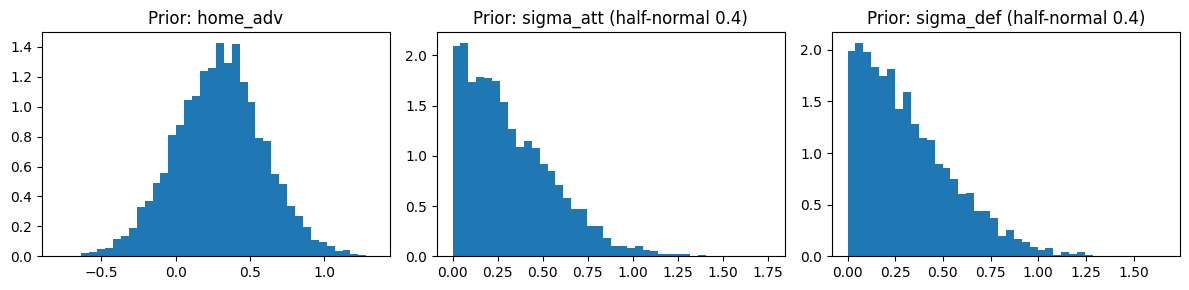

Prior sigma_att: mean=0.32, 95% CI [0.01, 0.90]
Implied att spread (sd): 0.401


In [33]:
rng = np.random.default_rng(42)
n_prior = 5000
T, S = stan_data["T"], stan_data["S"]

home_adv_prior = rng.normal(0.3, 0.3, size=n_prior)
# Match stan/hierarchical.stan: normal(0, 0.4) T[0,]
sigma_att_prior = np.abs(rng.normal(0, 0.4, size=n_prior))
sigma_def_prior = np.abs(rng.normal(0, 0.4, size=n_prior))

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].hist(home_adv_prior, bins=40, density=True)
axes[0].set_title("Prior: home_adv")
axes[1].hist(sigma_att_prior, bins=40, density=True)
axes[1].set_title("Prior: sigma_att (half-normal 0.4)")
axes[2].hist(sigma_def_prior, bins=40, density=True)
axes[2].set_title("Prior: sigma_def (half-normal 0.4)")
plt.tight_layout()
plt.show()

att_z = rng.normal(0, 1, size=(n_prior, T))
att_prior = sigma_att_prior[:, None] * att_z
att_prior -= att_prior.mean(axis=1, keepdims=True)
print(f"Prior sigma_att: mean={sigma_att_prior.mean():.2f}, 95% CI [{np.percentile(sigma_att_prior, 2.5):.2f}, {np.percentile(sigma_att_prior, 97.5):.2f}]")
print(f"Implied att spread (sd): {att_prior.std():.3f}")


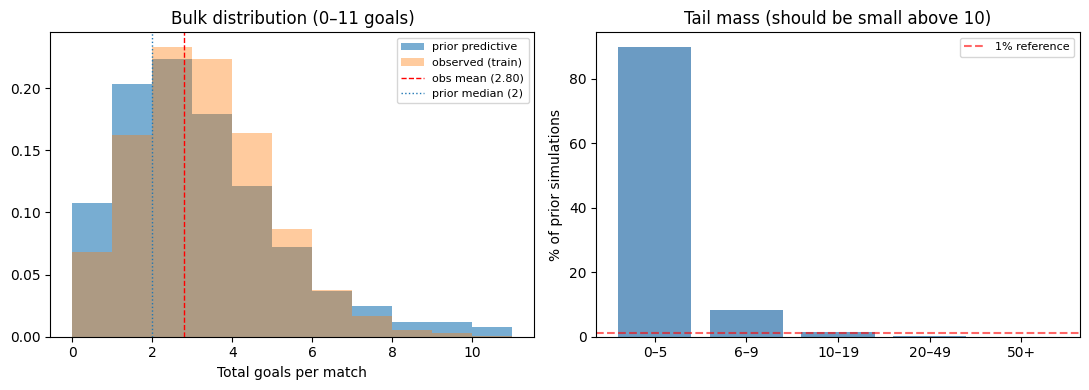

Prior predictive vs observed (training matches):
  mean   : prior 2.83  |  observed 2.80
  median : prior 2.0  |  observed 3.0
  5–95%  : prior [0, 7]  |  observed [0, 6]
  P(>10 goals): 1.18%  (should be low for a plausible football prior)


In [34]:
# Prior predictive — measurements (exact generative prior, no clipping)
n_matches_sim = 5000
total_goals_prior = np.empty(n_matches_sim)

for i in range(n_matches_sim):
    ha = rng.choice(home_adv_prior)
    sig_a, sig_d = rng.choice(sigma_att_prior), rng.choice(sigma_def_prior)
    az_ = rng.normal(0, 1, T)
    dz_ = rng.normal(0, 1, T)
    att = sig_a * az_
    att -= att.mean()
    def_ = sig_d * dz_
    def_ -= def_.mean()
    hi, ai = rng.integers(0, T, size=2)
    lh = np.exp(ha + att[hi] - def_[ai])
    la = np.exp(att[ai] - def_[hi])
    total_goals_prior[i] = rng.poisson(lh) + rng.poisson(la)

train_subset = matches[matches["season"].isin(TRAIN_SEASONS)]
obs_goals = train_subset["FTHG"] + train_subset["FTAG"]
obs_mean = obs_goals.mean()

# Summary statistics (mean is sensitive to rare tail draws — report several)
q = np.percentile(total_goals_prior, [5, 50, 95])
p_extreme = 100 * (total_goals_prior > 10).mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(total_goals_prior, bins=range(0, 12), density=True, alpha=0.6, label="prior predictive")
axes[0].hist(obs_goals, bins=range(0, 12), density=True, alpha=0.4, label="observed (train)")
axes[0].axvline(obs_mean, color="red", ls="--", lw=1, label=f"obs mean ({obs_mean:.2f})")
axes[0].axvline(q[1], color="C0", ls=":", lw=1, label=f"prior median ({q[1]:.0f})")
axes[0].set_xlabel("Total goals per match")
axes[0].set_title("Bulk distribution (0–11 goals)")
axes[0].legend(fontsize=8)

# Tail: how often does prior imply extreme scorelines?
tail_bins = [0, 6, 10, 20, 50, max(int(total_goals_prior.max()) + 1, 51)]
tail_labels = ["0–5", "6–9", "10–19", "20–49", "50+"]
tail_counts = np.histogram(total_goals_prior, bins=tail_bins)[0]
axes[1].bar(tail_labels, 100 * tail_counts / n_matches_sim, color="steelblue", alpha=0.8)
axes[1].set_ylabel("% of prior simulations")
axes[1].set_title("Tail mass (should be small above 10)")
axes[1].axhline(1.0, color="red", ls="--", alpha=0.6, label="1% reference")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Prior predictive vs observed (training matches):")
print(f"  mean   : prior {total_goals_prior.mean():.2f}  |  observed {obs_mean:.2f}")
print(f"  median : prior {q[1]:.1f}  |  observed {obs_goals.median():.1f}")
print(f"  5–95%  : prior [{q[0]:.0f}, {q[2]:.0f}]  |  observed [{obs_goals.quantile(0.05):.0f}, {obs_goals.quantile(0.95):.0f}]")
print(f"  P(>10 goals): {p_extreme:.2f}%  (should be low for a plausible football prior)")


**Prior predictive — interpretation**

- We simulate from the **same priors as Stan** (no clipping). Good prior: bulk histogram overlaps observed; **P(>10 goals)** is small.
- **Initial choice** $\text{Exp}(1)$ on $\sigma$ produced a heavy tail (arithmetic mean meaningless). **Fix:** half-normal $\mathcal{N}(0, 0.4)\,T[0,]$, calibrated via this check.
- For reporting, prefer **median and quantiles** over mean when tails exist.


### Fit Stan model

In [35]:
model = CmdStanModel(stan_file="stan/hierarchical.stan")
fit = model.sample(
    data=stan_data,
    seed=42,
    chains=4,
    parallel_chains=4,
    iter_warmup=1500,
    iter_sampling=1500,
    show_progress=True,
)
print(fit.diagnose())

08:00:59 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

08:01:41 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



### Sampling diagnostics (Model 2)

4 chains × (1500 warmup + 1500 sampling). Hierarchical models often need **longer warmup** than Model 1.

**Issues that may appear:** CmdStan can warn about low ESS or high $\hat{R}$ for some `att_z`/`def_z` entries when $S \times T$ is large.

**Mitigation used / available:**
- Non-centered parameterization (`att_z`, `def_z`) — already in `stan/hierarchical.stan`
- Increased warmup/sampling iterations (1500 vs 1000)
- If needed: raise `adapt_delta` (e.g. 0.95), reduce correlation via stronger priors on `sigma_*`

Check `fit.diagnose()` output below and compare $\hat{R}$, ESS, divergences.


In [36]:
fit.summary().loc[["home_adv", "sigma_att", "sigma_def", "lp__"]]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
home_adv,0.289481,0.000211,0.014617,0.014670,0.265552,0.289701,0.313085,4821.91,4366.44,1.00073
sigma_att,0.303820,0.000437,0.015572,0.015442,0.279376,0.303254,0.329815,1276.49,2539.25,1.00231
sigma_def,0.224557,0.000286,0.013074,0.012896,0.203813,0.224250,0.246925,2106.78,3340.07,1.00060
lp__,-10824.700000,0.777510,30.879200,31.134600,-10876.400000,-10824.100000,-10773.700000,1585.33,2754.62,1.00113


### Marginal posterior distributions (Model 2)

Focus on **hyperparameters** (`home_adv`, `sigma_att`, `sigma_def`) and the **last training season** team effects used for forecasting.


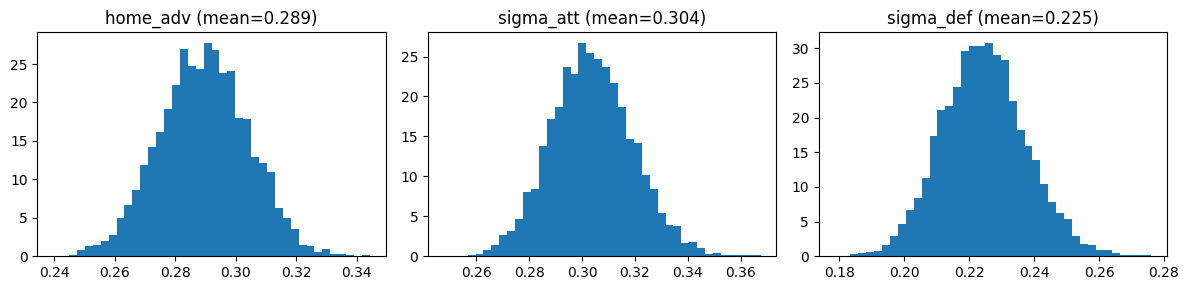

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
home_adv   0.289  0.015   0.263    0.318        0.0      0.0    4822.0   
sigma_att  0.304  0.016   0.275    0.333        0.0      0.0    1276.0   
sigma_def  0.225  0.013   0.200    0.249        0.0      0.0    2107.0   

           ess_tail  r_hat  
home_adv     4366.0    1.0  
sigma_att    2539.0    1.0  
sigma_def    3340.0    1.0  


In [37]:
idata = az.from_cmdstanpy(fit)
ha = fit.stan_variable("home_adv")
sa = fit.stan_variable("sigma_att")
sd = fit.stan_variable("sigma_def")

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].hist(ha, bins=40, density=True)
axes[0].set_title(f"home_adv (mean={ha.mean():.3f})")
axes[1].hist(sa, bins=40, density=True)
axes[1].set_title(f"sigma_att (mean={sa.mean():.3f})")
axes[2].hist(sd, bins=40, density=True)
axes[2].set_title(f"sigma_def (mean={sd.mean():.3f})")
plt.tight_layout()
plt.show()

print(az.summary(idata, var_names=["home_adv", "sigma_att", "sigma_def"]))


### Team strengths in the last training season

In [38]:
s_idx = last_season_idx - 1
att_last = fit.stan_variable("att")[:, s_idx, :].mean(axis=0)
def_last = fit.stan_variable("def")[:, s_idx, :].mean(axis=0)
idx_to_team = {i: t for t, i in team_to_idx.items()}

strengths = pd.DataFrame({
    "team": [idx_to_team[j + 1] for j in range(len(att_last))],
    "att": att_last,
    "def": def_last,
}).sort_values("att", ascending=False)

strengths.head(10)

,team,att,def
20,Liverpool,0.498237,0.140009
22,Man City,0.331407,0.099897
0,Arsenal,0.291822,0.263079
25,Newcastle,0.284187,0.054341
8,Brighton,0.264395,-0.110950
7,Brentford,0.263911,-0.084586
36,Tottenham,0.238269,-0.186364
11,Chelsea,0.225573,0.118242
1,Aston Villa,0.143983,0.003757
6,Bournemouth,0.140657,0.077089


### Example: one team's attack over seasons

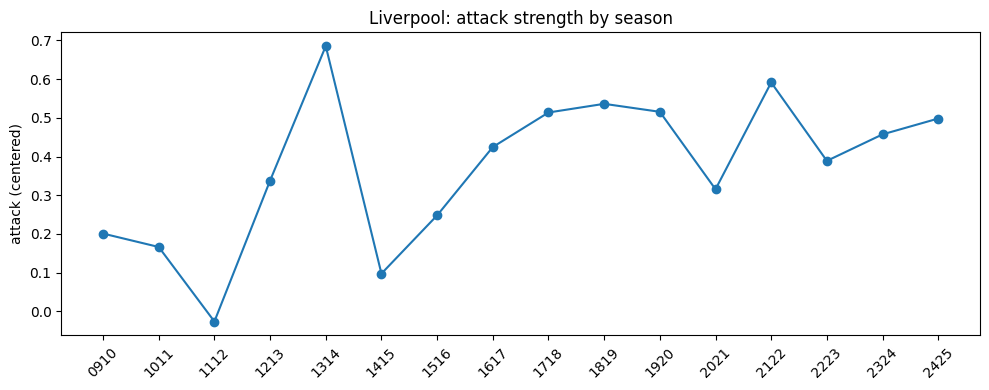

In [39]:
example_team = "Liverpool"
if example_team in team_to_idx:
    j = team_to_idx[example_team] - 1
    att_ts = fit.stan_variable("att")[:, :, j].mean(axis=0)
    seasons = list(season_to_idx.keys())
    plt.figure(figsize=(10, 4))
    plt.plot(seasons, att_ts, marker="o")
    plt.xticks(rotation=45)
    plt.ylabel("attack (centered)")
    plt.title(f"{example_team}: attack strength by season")
    plt.tight_layout()
    plt.show()

### Simulate 2025/26 table & compare to actual

In [40]:
pred_summary = simulate_seasons_from_hierarchical_draws(
    fit, test_teams, team_to_idx, last_season_index=last_season_idx, n_table_sims=500
)
actual = compute_table(matches, TEST_SEASON)[["team", "position", "Pts"]]
actual = actual.rename(columns={"position": "pos_actual", "Pts": "pts_actual"})

comparison = pred_summary.merge(actual, on="team", how="left")
comparison["pos_error"] = comparison["pos_median"] - comparison["pos_actual"]
comparison.sort_values("pos_actual")


,team,pos_median,pos_mean,pts_median,pts_mean,pos_actual,pts_actual,pos_error
1,Arsenal,3.0,4.342,67.0,66.604,1,85,2.0
2,Man City,5.0,6.024,63.0,62.266,2,78,3.0
16,Man United,15.0,14.522,43.0,43.556,3,71,12.0
7,Aston Villa,10.0,10.352,53.0,52.220,4,65,6.0
0,Liverpool,2.0,3.202,70.0,70.560,5,60,-3.0
5,Bournemouth,9.0,9.388,54.5,54.526,6,57,3.0
14,Sunderland,14.0,13.254,45.0,45.736,7,54,7.0
9,Brighton,10.0,9.880,53.0,53.436,8,53,2.0
8,Brentford,10.0,10.180,53.0,52.936,9,53,1.0
3,Chelsea,6.0,7.116,59.0,59.436,10,52,-4.0


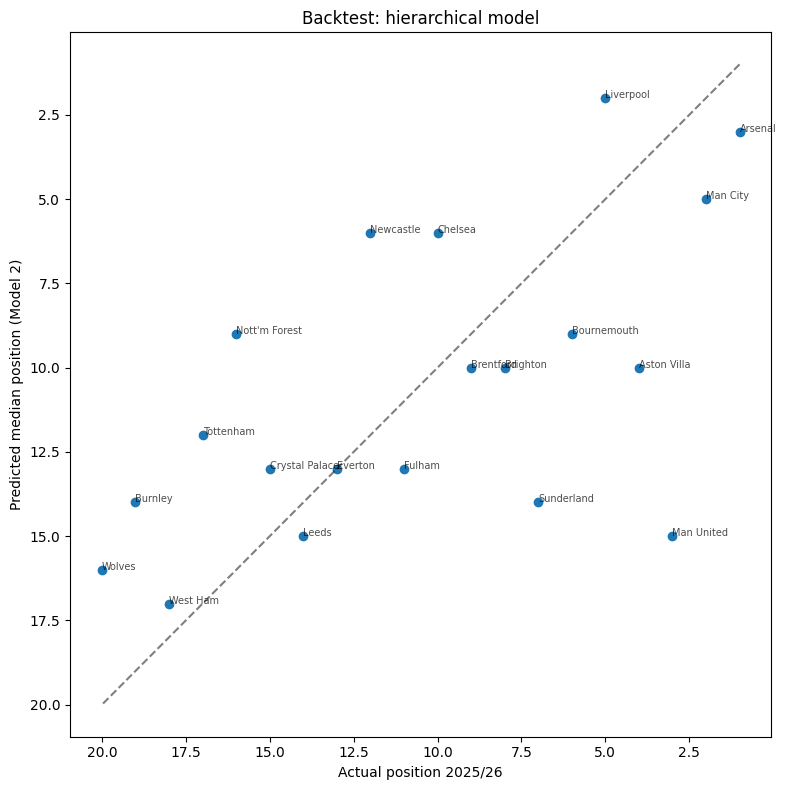

Mean absolute position error: 3.80


In [41]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(comparison["pos_actual"], comparison["pos_median"])
for _, r in comparison.iterrows():
    ax.annotate(r["team"], (r["pos_actual"], r["pos_median"]), fontsize=7, alpha=0.7)
ax.plot([1, 20], [1, 20], "k--", alpha=0.5)
ax.set_xlabel("Actual position 2025/26")
ax.set_ylabel("Predicted median position (Model 2)")
ax.set_title("Backtest: hierarchical model")
ax.invert_xaxis()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Mean absolute position error: {comparison['pos_error'].abs().mean():.2f}")

**Backtest interpretation (Model 2)**

Forecast uses **2024/25 season** strengths only — more reactive to recent form than Model 1's pooled estimate.  
Compare MAE with Model 1 (notebook 02); lower MAE suggests the hierarchical structure helps for this hold-out season.


### Posterior predictive check (pooled goals)

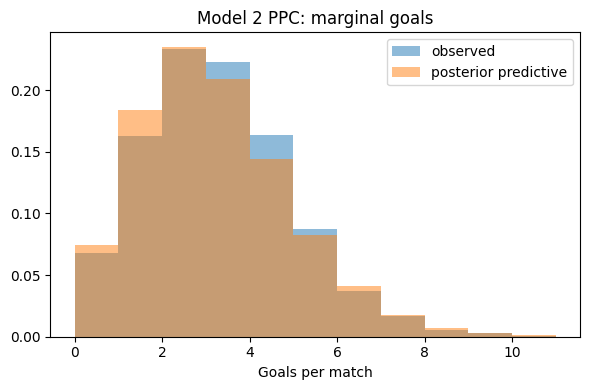

In [42]:
train = matches[matches["season"].isin(TRAIN_SEASONS)]
obs_goals = (train["FTHG"] + train["FTAG"]).values

att = fit.stan_variable("att")
def_ = fit.stan_variable("def")
ha = fit.stan_variable("home_adv")
rng = np.random.default_rng(1)

home_idx = stan_data["home"] - 1
away_idx = stan_data["away"] - 1
season_idx = stan_data["season"] - 1

rep_pooled = []
for _ in range(80):
    d = rng.integers(0, att.shape[0])
    for si, hi, ai in zip(season_idx, home_idx, away_idx):
        lh = np.exp(ha[d] + att[d, si, hi] - def_[d, si, ai])
        la = np.exp(att[d, si, ai] - def_[d, si, hi])
        rep_pooled.append(rng.poisson(lh) + rng.poisson(la))

rep_pooled = np.array(rep_pooled)
bins = range(0, 12)

plt.figure(figsize=(6, 4))
plt.hist(obs_goals, bins=bins, density=True, alpha=0.5, label="observed")
plt.hist(rep_pooled, bins=bins, density=True, alpha=0.5, label="posterior predictive")
plt.xlabel("Goals per match")
plt.legend()
plt.title("Model 2 PPC: marginal goals")
plt.tight_layout()
plt.show()

**Posterior predictive check — interpretation (Model 2)**

Same logic as Model 1: pooled replicated total goals should match the observed histogram.  
If Model 2 fits better at match level, the posterior predictive distribution may track extremes slightly better, but both models ignore within-match correlation (shots, game state).


### WAIC / LOO (Model 2 only)

Full model comparison on the **same training matches** is in notebook **04** (both models refit on all data through 2025/26).  
**Note:** If WAIC warns that `p_waic` variance is high, prefer **PSIS-LOO** for comparison (more robust).


In [43]:
# WAIC / LOO — requires full InferenceData (posterior + log_likelihood)
idata_m2 = az.from_cmdstanpy(fit)
waic_m2 = az.waic(idata_m2)
loo_m2 = az.loo(idata_m2)

print("Model 2 (hierarchical):")
print(waic_m2)
print(loo_m2)

# Save for comparison in notebook 04
M2_LOO_ELPd = float(loo_m2.elpd_loo)
M2_LOO_SE = float(loo_m2.se)
M2_WAIC_ELPd = float(waic_m2.elpd_waic)
print(f"\nStored: elpd_loo={M2_LOO_ELPd:.1f} ± {M2_LOO_SE:.1f}")


/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


Model 2 (hierarchical):
Computed from 6000 posterior samples and 6080 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -17855.48    73.86
p_waic      458.13        -

There has been a warning during the calculation. Please check the results.
Computed from 6000 posterior samples and 6080 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -17856.84    73.88
p_loo      459.49        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     6080  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%


Stored: elpd_loo=-17856.8 ± 73.9
